In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

1.Load data

In [2]:
import pandas as pd
df = pd.read_csv("Nat_Gas.csv")  # replace with your path

# Clean column names
df.columns = df.columns.str.strip().str.lower()
df.rename(columns={"dates": "date", "prices": "price"}, inplace=True)

# Convert 'date' column to datetime (let pandas infer format)
df["date"] = pd.to_datetime(df["date"], infer_datetime_format=True)

# Sort by date
df = df.sort_values("date").reset_index(drop=True)

# Quick check
print(df.head())
print(df.dtypes)


        date  price
0 2020-10-31   10.1
1 2020-11-30   10.3
2 2020-12-31   11.0
3 2021-01-31   10.9
4 2021-02-28   10.9
date     datetime64[ns]
price           float64
dtype: object


C:\Users\thymo\AppData\Local\Temp\ipykernel_19900\531706653.py:9: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df["date"] = pd.to_datetime(df["date"], infer_datetime_format=True)
C:\Users\thymo\AppData\Local\Temp\ipykernel_19900\531706653.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(df["date"], infer_datetime_format=True)


Visualize historical data

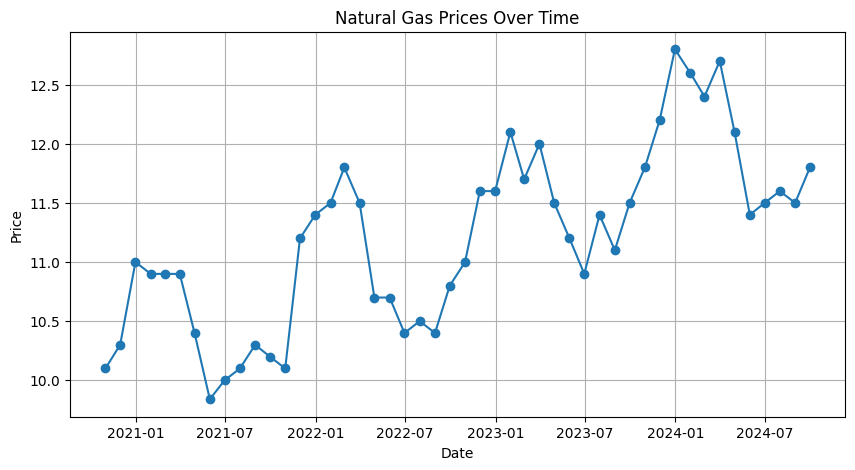

In [3]:
plt.figure(figsize=(10,5))
plt.plot(df["date"], df["price"], marker='o')
plt.title("Natural Gas Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()


Feature Engineering

In [4]:
# Time trend: number of days since first date
df["days"] = (df["date"] - df["date"].min()).dt.days

# Seasonality: monthly cycle using sin/cos
df["month"] = df["date"].dt.month
df["sin_month"] = np.sin(2 * np.pi * df["month"] / 12)
df["cos_month"] = np.cos(2 * np.pi * df["month"] / 12)


Train model

In [5]:
X = df[["days", "sin_month", "cos_month"]]
y = df["price"]

model = LinearRegression()
model.fit(X, y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Price prediction function

In [6]:
def get_price(input_date):
    input_date = pd.to_datetime(input_date)

    days = (input_date - df["date"].min()).days
    month = input_date.month
    sin_month = np.sin(2 * np.pi * month / 12)
    cos_month = np.cos(2 * np.pi * month / 12)

    # Pass as DataFrame with column names
    X_pred = pd.DataFrame([[days, sin_month, cos_month]],
                          columns=["days", "sin_month", "cos_month"])

    return float(model.predict(X_pred)[0])

Extrapolate 1 year into future

In [7]:
future_dates = pd.date_range(
    start=df["date"].max() + pd.DateOffset(days=1),
    end=df["date"].max() + pd.DateOffset(years=1),
    freq='ME'  # month-end
)

future_prices = [get_price(d) for d in future_dates]

Visualize historical + forecast

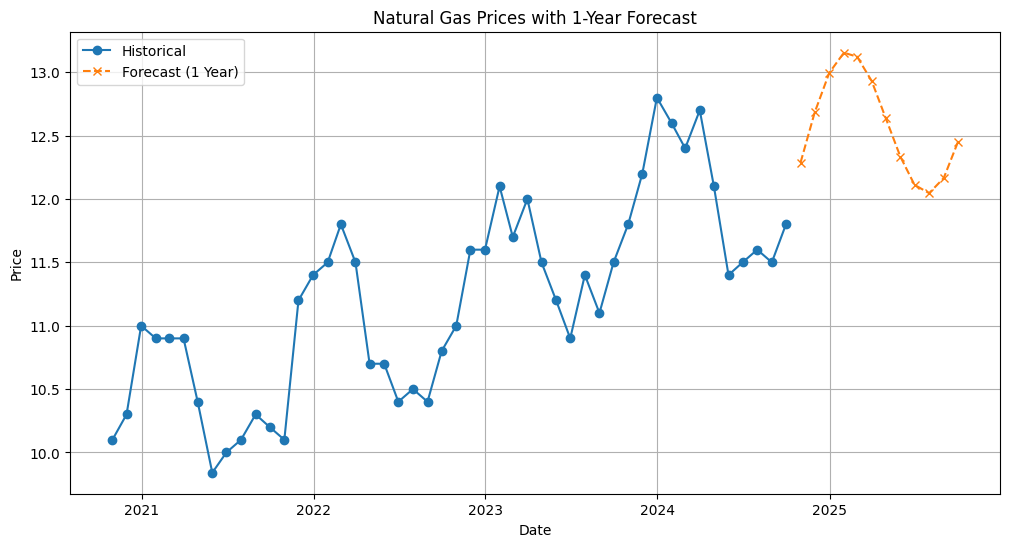

In [8]:
plt.figure(figsize=(12,6))

# Historical prices
plt.plot(df["date"], df["price"], label="Historical", marker='o')

# Forecast prices
plt.plot(future_dates, future_prices, label="Forecast (1 Year)", linestyle='--', marker='x')

plt.title("Natural Gas Prices with 1-Year Forecast")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()



Test Prediction Function

In [9]:
print("Estimated price on 2023-06-15:", get_price("2023-06-15"))  # past date
print("Estimated price on 2025-01-15:", get_price("2025-01-15"))  # future date

Estimated price on 2023-06-15: 10.992896189599906
Estimated price on 2025-01-15: 13.130106902700328


TASK 2 - Prototype function

In [10]:
import pandas as pd
import numpy as np

def price_storage_contract_multi(
    injection_dates,
    withdrawal_dates,
    volumes,
    max_volume,
    storage_fee_per_unit=0,
    injection_rate_per_day=np.inf,
    withdrawal_rate_per_day=np.inf
):
    total_value = 0
    current_storage = 0

    # Convert to datetime
    injection_dates = pd.to_datetime(injection_dates)
    withdrawal_dates = pd.to_datetime(withdrawal_dates)

    for inj, wdr, vol in zip(injection_dates, withdrawal_dates, volumes):
        # Enforce injection/withdrawal rates
        vol = min(vol, injection_rate_per_day, withdrawal_rate_per_day)

        # Enforce storage capacity
        if current_storage + vol > max_volume:
            vol = max_volume - current_storage
            if vol <= 0:
                print(f"Warning: Max storage reached on {inj.date()}")
                continue

        current_storage += vol

        # Prices
        purchase_price = get_price(inj)
        selling_price = get_price(wdr)

        # Storage months
        months = max(1, (wdr.to_period('M') - inj.to_period('M')).n)

        # Storage cost
        storage_cost = storage_fee_per_unit * vol * months

        # Value of this flow
        flow_value = (selling_price - purchase_price) * vol - storage_cost
        total_value += flow_value

        # Reduce storage after withdrawal
        current_storage -= vol

    return total_value

In [11]:
injection_dates = ["2024-06-01", "2024-07-01"]
withdrawal_dates = ["2024-10-01", "2024-12-01"]
volumes = [1e6, 0.5e6]  # MMBtu
max_volume = 2e6
storage_fee_per_unit = 100_000 / 1e6  # $100k per month per 1 million MMBtu

value = price_storage_contract_multi(
    injection_dates, withdrawal_dates, volumes, max_volume, storage_fee_per_unit
)

print("Estimated contract value:", value)

Estimated contract value: 820678.875628237
